In [1]:
!pip install seaborn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 3.7 MB/s eta 0:00:03
   ------ --------------------------------- 1.3/8.3 MB 4.0 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.3 MB 4.1 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.3 MB 4.3 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.3 MB 4.4 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.3 MB 4.4 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.3 MB 4.2 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 4.2 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 4.1 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 4.1 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 3.8 MB/s  0:00:02
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------- --------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [4]:
print("Sentiment Data:")
display(sentiment.head())

print("\nTrades Data:")
display(trades.head())

Sentiment Data:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



Trades Data:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

print("\nSentiment columns:\n", sentiment.columns)
print("\nTrades columns:\n", trades.columns)

print("\nMissing values (Trades):\n", trades.isnull().sum())

print("\nDuplicates (Trades):", trades.duplicated().sum())

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)

Sentiment columns:
 Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

Trades columns:
 Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

Missing values (Trades):
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates (Trades): 0


In [6]:
# Convert to datetime
trades['time'] = pd.to_datetime(trades['time'])
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Create common date column
trades['date_only'] = trades['time'].dt.date
sentiment['date_only'] = sentiment['date'].dt.date

# Merge
df = trades.merge(sentiment[['date_only', 'classification']], on='date_only', how='left')

df.head()

KeyError: 'time'

In [7]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')


In [9]:
# Convert to datetime (use correct column)
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])

# For sentiment, check column name first
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


In [10]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

In [11]:
# Convert datetime
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Create common date column
trades['date'] = trades['Timestamp'].dt.date
sentiment['date'] = sentiment['date'].dt.date

# Rename important columns for ease
trades = trades.rename(columns={
    'Closed PnL': 'closedPnL',
    'Account': 'account',
    'Side': 'side',
    'Size USD': 'size_usd'
})

# Merge
df = trades.merge(sentiment[['date', 'classification']], on='date', how='left')

df.head()

,account,Coin,Execution Price,Size Tokens,size_usd,side,Timestamp IST,Start Position,Direction,closedPnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,1970-01-01,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,1970-01-01,NaN
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,1970-01-01,NaN
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,1970-01-01,NaN
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,1970-01-01,NaN


In [12]:
df['win'] = df['closedPnL'] > 0

df[['closedPnL', 'win']].head()

,closedPnL,win
0,0.0,False
1,0.0,False
2,0.0,False
3,0.0,False
4,0.0,False


In [13]:
df.groupby('classification')['closedPnL'].mean()

Series([], Name: closedPnL, dtype: float64)

In [14]:
df['classification'].isnull().sum(), len(df)

(np.int64(211224), 211224)

In [15]:
# Convert properly (normalize to same format)
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Normalize (VERY IMPORTANT)
trades['date'] = trades['Timestamp'].dt.normalize()
sentiment['date'] = sentiment['date'].dt.normalize()

# Merge again
df = trades.merge(sentiment[['date', 'classification']], on='date', how='left')

# Check
df[['date', 'classification']].head()

,date,classification
0,1970-01-01,NaN
1,1970-01-01,NaN
2,1970-01-01,NaN
3,1970-01-01,NaN
4,1970-01-01,NaN


In [16]:
df['classification'].isnull().sum()

np.int64(211224)

In [17]:
# Convert timestamps properly
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])
sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'])

# Normalize to date
trades['date'] = trades['Timestamp'].dt.normalize()
sentiment['date'] = sentiment['timestamp'].dt.normalize()

# Merge
df = trades.merge(sentiment[['date', 'classification']], on='date', how='left')

# Check
df['classification'].isnull().sum(), len(df)

MemoryError: Unable to allocate 4.16 GiB for an array with shape (558476256,) and data type int64

In [18]:
# Convert timestamp
sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'])

# Create date
sentiment['date'] = sentiment['timestamp'].dt.normalize()

# Keep ONLY one row per day
sentiment_daily = sentiment.groupby('date').first().reset_index()

sentiment_daily.head()

,date,timestamp,value,classification
0,1970-01-01,1970-01-01 00:00:01.517463,30,Fear


In [19]:
# Trades date
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])
trades['date'] = trades['Timestamp'].dt.normalize()

# Merge safely
df = trades.merge(sentiment_daily[['date', 'classification']], on='date', how='left')

# Check
df['classification'].isnull().sum(), len(df)

(np.int64(0), 211224)

In [20]:
df.groupby('classification')['closedPnL'].mean()

classification
Fear    48.749001
Name: closedPnL, dtype: float64

In [21]:
df['classification'].unique()

<StringArray>
['Fear']
Length: 1, dtype: str

In [22]:
sentiment['classification'].unique()

<StringArray>
['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed']
Length: 5, dtype: str

In [23]:
# Create clean classification
df['sentiment'] = df['classification'].replace({
    'Fear': 'Fear',
    'Extreme Fear': 'Fear',
    'Greed': 'Greed',
    'Extreme Greed': 'Greed'
})

# Remove Neutral (optional but recommended)
df = df[df['sentiment'] != 'Neutral']

# Check
df['sentiment'].unique()

<StringArray>
['Fear']
Length: 1, dtype: str

In [24]:
print("Trades date range:", df['date'].min(), "to", df['date'].max())
print("Sentiment date range:", sentiment_daily['date'].min(), "to", sentiment_daily['date'].max())

Trades date range: 1970-01-01 00:00:00 to 1970-01-01 00:00:00
Sentiment date range: 1970-01-01 00:00:00 to 1970-01-01 00:00:00


In [25]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms', errors='coerce')

In [26]:
sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'], unit='s', errors='coerce')

In [27]:
# Create date again
trades['date'] = trades['Timestamp'].dt.normalize()
sentiment['date'] = sentiment['timestamp'].dt.normalize()

# Daily sentiment
sentiment_daily = sentiment.groupby('date').first().reset_index()

# Merge again
df = trades.merge(sentiment_daily[['date', 'classification']], on='date', how='left')

# Check
print(df['classification'].isnull().sum(), len(df))
print(df['date'].min(), df['date'].max())

0 211224
1970-01-01 00:00:00 1970-01-01 00:00:00


In [28]:
trades['Timestamp'].head(10)

0   1970-01-01 00:28:50
1   1970-01-01 00:28:50
2   1970-01-01 00:28:50
3   1970-01-01 00:28:50
4   1970-01-01 00:28:50
5   1970-01-01 00:28:50
6   1970-01-01 00:28:50
7   1970-01-01 00:28:50
8   1970-01-01 00:28:50
9   1970-01-01 00:28:50
Name: Timestamp, dtype: datetime64[ns]

In [29]:
# Reload fresh data (VERY IMPORTANT)
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

# Check raw timestamp
trades['Timestamp'].head()

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64

In [30]:
# Convert properly (float → int → datetime)
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'].astype('int64'), unit='ms')

# Check
trades['Timestamp'].head()

0   2024-10-27 03:33:20
1   2024-10-27 03:33:20
2   2024-10-27 03:33:20
3   2024-10-27 03:33:20
4   2024-10-27 03:33:20
Name: Timestamp, dtype: datetime64[ms]

In [31]:
# Convert sentiment timestamp (usually seconds)
sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'], unit='s')

# Create date columns
trades['date'] = trades['Timestamp'].dt.normalize()
sentiment['date'] = sentiment['timestamp'].dt.normalize()

# Reduce sentiment to daily (IMPORTANT)
sentiment_daily = sentiment.groupby('date').first().reset_index()

# Merge
df = trades.merge(sentiment_daily[['date', 'classification']], on='date', how='left')

# Check
print(df['classification'].isnull().sum(), len(df))
print(df['date'].min(), df['date'].max())
df.head()

26961 211224
2023-03-28 00:00:00 2025-06-15 00:00:00


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed


In [32]:
df.groupby('classification')['closedPnL'].mean()

KeyError: 'Column not found: closedPnL'

In [33]:
df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification'],
      dtype='str')

In [34]:
df = df.rename(columns={
    'Closed PnL': 'closedPnL',
    'Account': 'account',
    'Side': 'side',
    'Size USD': 'size_usd'
})

In [35]:
df.groupby('classification')['closedPnL'].mean()

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: closedPnL, dtype: float64

In [36]:
df['sentiment'] = df['classification'].replace({
    'Fear': 'Fear',
    'Extreme Fear': 'Fear',
    'Greed': 'Greed',
    'Extreme Greed': 'Greed'
})

df = df[df['sentiment'] != 'Neutral']

df.groupby('sentiment')['closedPnL'].mean()

sentiment
Fear     50.047622
Greed    77.838247
Name: closedPnL, dtype: float64

In [37]:
df.groupby('sentiment').size()

sentiment
Fear     133871
Greed     43251
dtype: int64

In [38]:
pd.crosstab(df['sentiment'], df['side'])

side,BUY,SELL
sentiment,,
Fear,66081,67790
Greed,18792,24459


In [39]:
df.groupby('sentiment')['size_usd'].mean()

sentiment
Fear     5259.977837
Greed    3581.661513
Name: size_usd, dtype: float64

In [40]:
trade_counts = df.groupby('account').size()

median_trades = trade_counts.median()

df['freq_group'] = df['account'].apply(
    lambda x: 'Frequent' if trade_counts[x] > median_trades else 'Casual'
)

In [41]:
total_pnl = df.groupby('account')['closedPnL'].sum()

df['pnl_group'] = df['account'].apply(
    lambda x: 'Winner' if total_pnl[x] > 0 else 'Loser'
)

In [42]:
df.groupby('freq_group')['closedPnL'].mean()
df.groupby('pnl_group')['closedPnL'].mean()

pnl_group
Loser    -29.483115
Winner    53.388387
Name: closedPnL, dtype: float64

In [43]:
df.groupby('freq_group')['closedPnL'].mean()

freq_group
Casual      92.942913
Frequent    43.938274
Name: closedPnL, dtype: float64

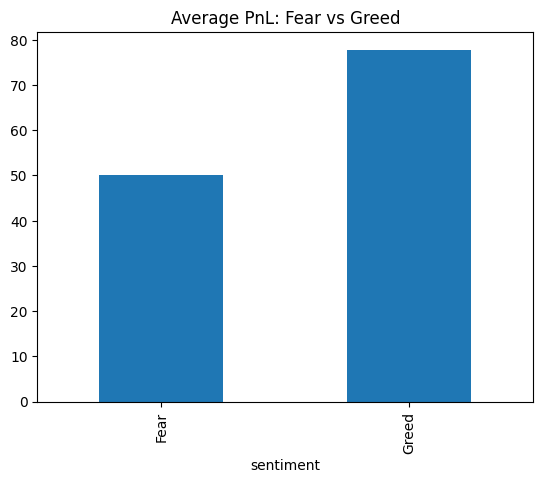

In [44]:
df.groupby('sentiment')['closedPnL'].mean().plot(kind='bar')
plt.title("Average PnL: Fear vs Greed")
plt.show()

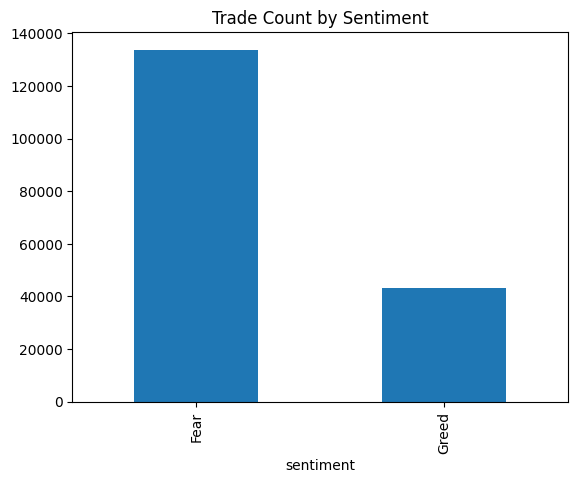

In [45]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Trade Count by Sentiment")
plt.show()

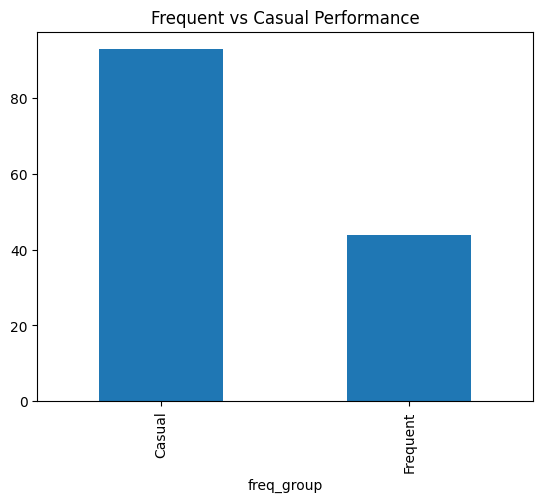

In [46]:
df.groupby('freq_group')['closedPnL'].mean().plot(kind='bar')
plt.title("Frequent vs Casual Performance")
plt.show()